In [ ]:
#CH.SC.U4CSE24111-Darunkumar J
#Logistic Regression Exercise 1

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [2]:
import pandas as pd

data = pd.read_csv("binary.csv")

print(data.shape)
data.head()

(400, 5)


,Unnamed: 0,admit,gre,gpa,rank
0,0,0.0,380.0,3.61,3.0
1,1,1.0,660.0,3.67,3.0
2,2,1.0,800.0,4.00,1.0
3,3,1.0,640.0,3.19,4.0
4,4,0.0,520.0,2.93,4.0


In [6]:
data.drop(columns=['Unnamed: 0'], inplace=True)

data.head()

,admit,gre,gpa,rank,rank_2.0,rank_3.0,rank_4.0
0,0.0,380.0,3.61,3.0,False,True,False
1,1.0,660.0,3.67,3.0,False,True,False
2,1.0,800.0,4.00,1.0,False,False,False
3,1.0,640.0,3.19,4.0,False,False,True
4,0.0,520.0,2.93,4.0,False,False,True


In [7]:
data.isnull().sum()

admit       0
gre         0
gpa         0
rank        0
rank_2.0    0
rank_3.0    0
rank_4.0    0
dtype: int64

In [8]:
data['rank'] = data['rank'].astype(int)

rank = pd.get_dummies(data['rank'], prefix='rank', drop_first=True)

data = pd.concat([data, rank], axis=1)

data.head()

,admit,gre,gpa,rank,rank_2.0,rank_3.0,rank_4.0,rank_2,rank_3,rank_4
0,0.0,380.0,3.61,3,False,True,False,False,True,False
1,1.0,660.0,3.67,3,False,True,False,False,True,False
2,1.0,800.0,4.00,1,False,False,False,False,False,False
3,1.0,640.0,3.19,4,False,False,True,False,False,True
4,0.0,520.0,2.93,4,False,False,True,False,False,True


In [9]:
feature_cols = ['gre', 'gpa', 'rank_2', 'rank_3', 'rank_4']

X = data[feature_cols]
y = data['admit']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=5
)

print("Training Features :", X_train.shape)
print("Training Labels   :", y_train.shape)
print("Testing Features  :", X_test.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (320, 5)
Training Labels   : (320,)
Testing Features  : (80, 5)
Testing Labels    : (80,)


In [11]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [12]:
y_pred = model.predict(X_test)

print(y_pred)

[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0.]


In [13]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_mat)

accuracy = metrics.accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy)
print("Accuracy Percentage :", round(accuracy * 100, 2), "%")

Confusion Matrix:
[[49  5]
 [25  1]]
Accuracy Score : 0.625
Accuracy Percentage : 62.5 %


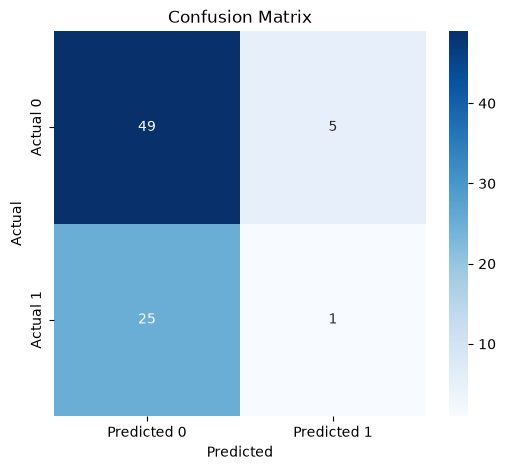

In [14]:
confusion_df = pd.DataFrame(
    conf_mat,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1']
)

plt.figure(figsize=(6,5))

sns.heatmap(confusion_df, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()